# State-Level Rational Agent Access Modeling (RAAM) of Opioid Treatment Program (OTP) Accessibility in Illinois

#### By: Yilin Lyu, Mallikarjun Bhusnoor
#### Last Updated: February 16, 2025

## Step 0: Setup & Imports

##### **Goal:** Prepare coding environment, data links, and constants

- Import required libraries (pandas, geopandas, access, etc.)
- Define Data Sources:
    - 2020 trac geometries (geographies20)
    - 2020 tract population (pop_data20)
    - 2025 Provider dataset (sample_point_data25)
    - 2020 national travel-time matrices (matrices20)

**Output**: Ready-to-use configuration for demand, supply, and cost construction

In [2]:
import os
os.environ['USE_PYGEOS'] = '1'

import pandas as pd
import geopandas as gpd
import io
import urllib
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

# Utility function: convert DataFrame with lon/lat to GeoDataFrame
def dfToGdf(df, lon, lat, crs='EPSG:4326'):
  '''
    df: pandas dataframe
    lon: longitude column name
    lat: latitude column name
    crs: EPSG code or similar coordinate reference system
  '''
  return gpd.GeoDataFrame(
    df.drop([lon, lat], axis=1),
    crs=crs,
    geometry=[Point(xy) for xy in zip(df[lon], df[lat])])

In [3]:
# 2010 base vintage, 2018 edition
# Update S3 links
matrices10 = {
    'tract': {
        'car':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/US-matrix-TRACT-DRIVING.parquet',
        'bike':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/US-matrix-TRACT-BICYCLE.parquet',
        'walk':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/US-matrix-TRACT-WALKING.parquet'
    }
}

# 2020 base vintage
matrices20 = {
    'tract': {
        'car':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Drive-192km-90min.parquet',
        'bike':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Bike-24km-90min.parquet',
        'walk':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Walk-6km-90min.parquet'
    }
}

# 2010 base vintage, 2018 edition
geographies10 = {
    'tract': 'https://herop-geodata.s3.us-east-2.amazonaws.com/census/tract-2010-500k-shp.zip',
    'zip': 'https://herop-geodata.s3.us-east-2.amazonaws.com/census/zcta-2010-500k-shp.zip'
}

# 2020 base vintage
geographies20 = {
    'tract': 'https://herop-geodata.s3.us-east-2.amazonaws.com/census/tract-2020-500k-shp.zip',
    'zip':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/zcta-2020-500k-shp.zip'
}

pop_data10 = {
    'tract':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/R12960863_SL140.csv'
}

# 2020 base vintage
pop_data20 = {
    'tract':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/tract-2020.csv'
}

sample_point_data19 = {
    'FQHC': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/context_fqhc_clinics_hrsa.csv',
    'pharmacies': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/R13095719_SL860.csv',
    'opioid_treatment_facilities': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/Opioid_Treatment_Directory_Geocoded.csv',
    'moud_full': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded.csv',
    'moud1': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded1.csv',
    'moud2': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded2.csv',
    'moud3': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded3.csv'
}

sample_point_data25 = {
    'FQHC': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/context_fqhc_clinics_hrsa.csv',
    'MET' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/MET_2025.csv',
    'OTPR_N' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/Opioid_Treatemnt_Programs_2025_G.csv',
    'BUP' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/BUP_2025.csv',
    'NAL_TELE' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/Naltrexone_Telehealth_2025.csv',
    'NAL' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/NAL_2025.csv',
    'SUPPORTIVE' : 'https://raw.githubusercontent.com/healthyregions/loud-study/refs/heads/main/indicators_raw/us-supportive-services.csv',
    'ABSTINENCE' : 'https://raw.githubusercontent.com/healthyregions/loud-study/refs/heads/main/indicators_raw/us-abstinence-services2.csv',
    'PHARM' : 'https://raw.githubusercontent.com/healthyregions/loud-study/refs/heads/main/indicators_raw/Pharmacy.csv'
}

geoid_cols = {
    "tract":"GEOID",
    "zip": "GEOID10"
}

## Step 1: Prepare Demand (Where People Live)

##### **Goal:**
- Attach 2020 population counts to each Illinois census tract so that RAAM can quantify how many people (demand) are seeking care from each location.
**Output**:
- **GEOGRAPHIES_IL:** Illinois tract polygons with attached demand values
- **demand_df:** RAAM-ready demand table indexed by GEOID, containing one demand value per tract

#### 1.1 Subset Illinois Tract Geometries
- Load 2020 national tract geometries
- Standardize GEOID to 11-character strings
- Filter to Illinois (STATEFP = "17")
- Check number of Illinois tracts

In [4]:
# National tract geometries (2020, all states)
GEOGRAPHIES_US = gpd.read_file(geographies20["tract"]).to_crs("EPSG:4326")

# Standardize GEOID to 11-character string
GEOGRAPHIES_US["GEOID"] = GEOGRAPHIES_US["GEOID"].astype(str).str.zfill(11)

# Illinois identification
STATE_ABBR = "IL"       # Illinois state abbreviation
STATEFP_IL = "17"       # Illinois state FIPS

# Subset to Illinois tracts only
GEOGRAPHIES_IL = GEOGRAPHIES_US[GEOGRAPHIES_US["STATEFP"] == STATEFP_IL].copy()

# Check tract number
print("Illinois tract count:", len(GEOGRAPHIES_IL))

Illinois tract count: 3263


#### 1.2 Build Demand Table (Population) for RAAM

- Load tract-level population data (pop_data20)
- Standardize column names in demand table (FIPS, TotPopHh) with previous geometry table
- Keep only tracts present in Illinois geometry

In [5]:
# Load tract-level population (2020 vintage, national)
POPULATION_US = pd.read_csv(pop_data20["tract"])

# Take a quick look
POPULATION_US.head()

,HEROP_ID,FIPS,MetRm30,MetRm60,MetRm90,NaltRm30,NaltRm60,NaltRm90,BupRm30,BupRm60,...,VetP,DisbP,TotPopHh,NonRelFhhP,NonRelNfhhP,SviTh1,SviTh2,SviTh3,SviTh4,SviSmryRnk
0,140US01001020100,1001020100,2.630,1.899,1.666,4.837,3.977,3.513,3.279,2.324,...,11.7,21.3,1941.0,6.8,1.9,0.4578,0.5079,0.3921,0.0945,0.2823
1,140US01001020200,1001020200,2.552,1.860,1.640,4.769,3.937,3.486,3.195,2.411,...,10.4,11.0,1545.0,16.6,2.4,0.5348,0.0810,0.7610,0.7915,0.5406
2,140US01001020300,1001020300,2.411,1.790,1.593,4.618,3.873,3.444,3.120,2.247,...,13.7,14.0,3694.0,9.2,4.5,0.3639,0.8632,0.5529,0.3500,0.5042
3,140US01001020400,1001020400,2.448,1.809,1.606,4.689,3.881,3.439,2.899,2.325,...,15.2,19.6,3539.0,3.5,4.6,0.2081,0.8131,0.2386,0.1759,0.2703
4,140US01001020500,1001020500,2.504,1.836,1.624,4.730,3.899,3.457,2.924,2.386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# The population table has:
#   - FIPS: full tract GEOID (as string or number)
#   - TotPopHh: total population in households per tract
#
# We:
#   - standardize FIPS to 11-digit strings
#   - rename TotPopHh -> 'demand'
#   - rename FIPS -> GEOID so it matches GEOGRAPHIES_US
#   - keep only tracts that exist in the geometry layer
#   - keep only Illinois tracts (match GEOGRAPHIES_IL)

# Ensure FIPS is zero-padded 11-char string
POPULATION_US["FIPS"] = POPULATION_US["FIPS"].astype(str).str.zfill(11)

# Use total population in households as demand
POPULATION_US = POPULATION_US.rename(columns={"TotPopHh": "demand"})

# Keep only what's needed and standardize column names
DEMAND_US = POPULATION_US[["FIPS", "demand"]].copy()
DEMAND_US = DEMAND_US.rename(columns={"FIPS": "GEOID"})

# Make sure we only keep tracts that are in the national tract layer
DEMAND_US = DEMAND_US[DEMAND_US["GEOID"].isin(GEOGRAPHIES_US["GEOID"])]

# Illinois-only demand table (match to IL tract layer)
DEMAND_IL = DEMAND_US[DEMAND_US["GEOID"].isin(GEOGRAPHIES_IL["GEOID"])].copy()

# Check the result
DEMAND_IL.head()

,GEOID,demand
28957,17001000100,4588.0
28958,17001000201,1976.0
28959,17001000202,2349.0
28960,17001000400,3028.0
28961,17001000500,1883.0


#### 1.3 Attach Demand to Geometry

- Merge demand onto Illinois tract polygons
- Create **demand_df** for RAAM calculation

In [7]:
# Merge population to Illinois tract geometries
#   - keep ALL tracts (even if demand is missing)
GEOGRAPHIES_IL = GEOGRAPHIES_IL.merge(
    DEMAND_IL,       # has columns ['GEOID', 'demand']
    on="GEOID",
    how="left"
)

# Instead of dropping NAs, treat missing demand as 0
#   - so unpopulated / missing tracts are kept
GEOGRAPHIES_IL["demand"] = GEOGRAPHIES_IL["demand"].fillna(0)

# Make sure demand is numeric
GEOGRAPHIES_IL["demand"] = GEOGRAPHIES_IL["demand"].astype(float)

# Build the demand_df for RAAM (Illinois-only):
#   - create demand_df with index = GEOID, column = 'demand'
demand_df = GEOGRAPHIES_IL[["GEOID", "demand"]].copy()
demand_df = demand_df.set_index("GEOID")

# Preview the demand table
demand_df.head()

,demand
GEOID,
17143003000,5192.0
17143004300,2107.0
17073030600,2937.0
17073030900,3390.0
17019001205,7414.0


## Step 2: Prepare Supply: Providers Per Tract

##### **Goal:**
- Identify which Illinois census tract each OTP provider falls into and aggregate providers to the tract level to construct a tract-level supply measure for RAAM. Please note that this Illinois version sample script restricts both origins and destinations to Illinois. Cross-state travel to providers in neighboring states is not included.
**Output**:
- **supply_df:** RAAM-ready supply table indexed by GEOID, containing one supply value per tract

#### 2.1 Load Opioid Treatment Programs (OTP Provider) Points
- Read **OTPR_N** dataset
- Convert longitude/latitude into a GeoDataFrame

In [8]:
# This is optional, for debugging lon/lat field names
df_otpr = pd.read_csv(sample_point_data25["OTPR_N"])
print("OTPR_N columns:\n", df_otpr.columns.tolist(), "\n")

OTPR_N columns:
 ['Unnamed: 0', '    name1', 'name2', 'street1', 'street2', 'city', 'state', 'zip', 'zip4', 'county', 'phone', 'intake_prompt', 'intake1', 'intake2', 'website', 'latitude', 'longitude', 'type_facility '] 



In [9]:
def load_moud_points(url, lon_col="longitude", lat_col="latitude"):
    df = pd.read_csv(url)
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"
    )

# Load national OTPR_N provider dataset and convert to spatial points
otpr_gdf = load_moud_points(sample_point_data25["OTPR_N"])

otpr_gdf.head()

,Unnamed: 0,name1,name2,street1,street2,city,state,zip,zip4,county,phone,intake_prompt,intake1,intake2,website,latitude,longitude,type_facility,geometry
0,0,Denver Recovery Group - Glenwood Springs,NTP,1429 Grand Avenue,NaN,Glenwood Springs,CO,81401,NaN,NaN,(720) 940-3813,NaN,NaN,NaN,NaN,39.538272,-107.325524,OTP,POINT (-107.32552 39.53827)
1,1,Denver Recovery Group - Montrose,NTP,130 North Park,NaN,Montrose,CO,81401,NaN,NaN,(720) 940-3813,NaN,NaN,NaN,NaN,38.482324,-107.875673,OTP,POINT (-107.87567 38.48232)
2,2,"VCPHCS XII, LLC",BHG Colorado Springs Treatment Center,4157 Centenniel Blvd,NaN,Colorado Springs,CO,80907,NaN,NaN,(719) 598-9750,NaN,NaN,NaN,NaN,38.892567,-104.849195,OTP,POINT (-104.84919 38.89257)
3,3,Denver Recovery Group - Colorado Springs,ALT Recovery Group,2531 Airport Road,NaN,Colorado Springs,CO,80910,NaN,NaN,(719) 300-7021,NaN,NaN,NaN,NaN,38.825251,-104.782415,OTP,POINT (-104.78241 38.82525)
4,4,Colorado Treatment Services LLC,NaN,"5360 N Academy Blvd,Suite 290",NaN,Colorado Springs,CO,80918,NaN,NaN,(719) 434-2061,NaN,NaN,NaN,NaN,38.906095,-104.779668,OTP,POINT (-104.77967 38.90609)


#### 2.2 Spatial Join to Illinois Tracts
- Spatially join OTP points to Illinois tract polygons
- Assign each provider to a tract

In [10]:
# Ensure Illinois tracts are in geographic coordinate system (EPSG:4326)
GEOGRAPHIES_IL = GEOGRAPHIES_IL.to_crs("EPSG:4326")

def join_to_tracts(provider_gdf, tracts_gdf, tract_id_col="GEOID"):
    """
    Spatially join provider points to tract polygons.

    provider_gdf: GeoDataFrame of points (e.g., OTP sites)
    tracts_gdf:   GeoDataFrame of tract polygons with a tract_id_col (e.g., GEOID)
    """
    provider_gdf = provider_gdf.to_crs(tracts_gdf.crs)
    joined = gpd.sjoin(
        provider_gdf,
        tracts_gdf[[tract_id_col, "geometry"]],
        how="inner",
        predicate="within"
    )
    return joined

# Join OTPR_N dataset to Illinois tracts
otpr_join = join_to_tracts(otpr_gdf, GEOGRAPHIES_IL)

#### 2.3 Aggregate to Tract-Level Supply
- Count how many OTP providers fall in each tract within Illinois
- Create **supply_df** for RAAM calculation

In [11]:
# Count OTP providers in tract
otpr_counts = otpr_join.groupby("GEOID").size().rename("otp_count")

# OTP-only supply_df that will be use in the RAAM later
#   - create demand_df with index = GEOID, column = 'demand'
supply_df = otpr_counts.to_frame(name="supply")

# Make sure GEOID is a proper 11-digit string
supply_df.index = supply_df.index.astype(str).str.zfill(11)
supply_df.index.name = "GEOID"

supply_df.head()

,supply
GEOID,
17001000700,1
17019000700,1
17019001000,1
17019011100,1
17031050600,1


## Step 3: Prepare Travel-Time Cost Matrix

##### **Goal:**
- Construct an Illinois-only origin–destination travel-time matrix so that RAAM can measure the travel cost from each demand tract (where people live) to each supply tract (where OTP providers are located).
**Output**:
- **cost_df:** RAAM-ready cost table with columns: origin, dest, cost in minutes, Illinois-only

#### 3.1 Set Geographic Unit and Travel Mode
- GEOGRAPHIC_UNIT = "tract"
- TRANSIT_MODE = "car"

In [12]:
GEOGRAPHIC_UNIT = "tract"

# Choose travel mode ("car", "bike", "walk")
TRANSIT_MODE = "car"       # change here if you want bike or walk

#### 3.2 Load National Travel-Time Matrix
  - origin
  - destination
  - minutes

In [13]:
import io
import requests
import pyarrow.parquet as pq

# Get the URL for the selected geographic unit + mode
matrix_url = matrices20[GEOGRAPHIC_UNIT][TRANSIT_MODE]
print("Loading matrix from:", matrix_url)

# Download the file into memory
resp = requests.get(matrix_url)
resp.raise_for_status()       # will error clearly if download fails

# Wrap bytes in a file-like buffer
buffer = io.BytesIO(resp.content)

# Read parquet from the in-memory buffer
pf = pq.ParquetFile(buffer)
TRANSIT_MATRIX = pf.read().to_pandas()

TRANSIT_MATRIX.head()

Loading matrix from: https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Drive-192km-90min.parquet


,origin,destination,minutes
0,28047003506,01097000200,86.491667
1,28047003506,01097000401,87.965000
2,28047003506,01097000402,88.440000
3,28047003506,01097000500,88.363333
4,28047003506,01097000600,89.540000


#### 3.3 Restrict to Illinois Demand & Supply
- **Origin** is a tract in Illinois (i.e., in GEOGRAPHIES_IL / demand_df index)
- **Destination** is a tract in Illinois that has OTP supply (i.e., in supply_df index)
- Restrict both origins and destinations to Illinois for this state sample script

In [14]:
# Standardize IDs to 11-digit strings first
TRANSIT_MATRIX["origin"]      = TRANSIT_MATRIX["origin"].astype(str).str.zfill(11)
TRANSIT_MATRIX["destination"] = TRANSIT_MATRIX["destination"].astype(str).str.zfill(11)

# All Illinois tract IDs with demand
demand_ids = set(demand_df.index)       # demand_df was built from GEOGRAPHIES_IL

# All Illinois tract IDs that have OTP supply (Illinois-only)
supply_ids = set(supply_df.index)       # supply_df was built from OTPR_N joined to GEOGRAPHIES_IL

# Keep only rows where:
#   - origin is an Illinois tract (demand)
#   - destination is an Illinois tract with OTP supply
cost_df = TRANSIT_MATRIX[
    TRANSIT_MATRIX["origin"].isin(demand_ids) &
    TRANSIT_MATRIX["destination"].isin(supply_ids)
].copy()

# OPTIONALLY, filter out very long trips (e.g., > 90 minutes) if needed
# IMPORTANT: do not drop 0-minute trips (0 can indicate perfect access / same-tract supply)
cost_df = cost_df[cost_df["minutes"] <= 90].copy()

# Rename columns to what RAAM expects
cost_df = cost_df.rename(columns={
    "destination": "dest",
    "minutes": "cost"
})

cost_df.head()

,origin,dest,cost
93694168,17137951900,17001000700,76.981667
93694282,17137951900,17167001800,39.841667
93694295,17137951900,17167002900,33.578333
93694315,17137951900,17167004200,42.106667
93694629,17001001002,17001000700,4.508333


## Step 4: Run Rational Agent Access Model (RAAM)

##### **Goal:**
- Use the Illinois-only demand_df, supply_df, and cost_df as inputs to the PySAL access.raam function to compute tract-level RAAM accessibility costs (incorporating both travel time and congestion), where lower values indicate better access.
**Output**:
- **raam_30** & **raam_60**: RAAM scores
- **GEOGRAPHIES_IL**: Illinois tract polygons with attached RAAM_30 and RAAM_60 columns for mapping and export

#### 4.1 Import required package for RAAM

In [15]:
# If 'access' is already installed in your environment, you can skip the pip line.
!pip install access

import access

# Sanity check shapes
print("Demand locations:", demand_df.shape[0])
print("Supply locations:", supply_df.shape[0])
print("Cost matrix rows:", cost_df.shape[0])

Defaulting to user installation because normal site-packages is not writeable
Demand locations: 3263
Supply locations: 88
Cost matrix rows: 158586


#### 4.2 Calculate RAAM Metrics
- Inputs: **demand_df**, **supply_df**, **cost_df**
- Run RAAM twice: 30 minutes vs 60 minutes

In [16]:
# RAAM with tau = 30 minutes (Illinois-only)
raam_30 = access.raam.raam(
    demand_df=demand_df,
    supply_df=supply_df,
    cost_df=cost_df,
    demand_index=True,
    demand_name="demand",
    supply_index=True,
    supply_name="supply",
    cost_origin="origin",
    cost_dest="dest",
    cost_name="cost",
    tau=30,
    rho=None,
    max_cycles=150,
    initial_step=0.2,
    min_step=0.005,
    half_life=50,
    verbose=False
)

# RAAM with tau = 60 minutes (Illinois-only)
raam_60 = access.raam.raam(
    demand_df=demand_df,
    supply_df=supply_df,
    cost_df=cost_df,
    demand_index=True,
    demand_name="demand",
    supply_index=True,
    supply_name="supply",
    cost_origin="origin",
    cost_dest="dest",
    cost_name="cost",
    tau=60,
    rho=None,
    max_cycles=150,
    initial_step=0.2,
    min_step=0.005,
    half_life=50,
    verbose=False
)

# RAAM returns a pandas Series indexed by Illinois demand tract GEOID
raam_30.head(), raam_60.head()

(17197881116    1.458213
 17153971100    4.161792
 17031824505    1.017055
 17081051100    4.032458
 17167003300    1.518546
 Name: RAAM, dtype: float64,
 17197881116    1.098991
 17153971100    3.365022
 17031824505    0.872783
 17081051100    3.300355
 17167003300    1.255875
 Name: RAAM, dtype: float64)

#### 4.3 Merge RAAM Results Back into the Illinois Tract Geometry

In [17]:
# raam_30 and raam_60 are pandas Series indexed by GEOID (Illinois demand tracts)
# Attach them to GEOGRAPHIES_IL so each Illinois tract has its RAAM scores

GEOGRAPHIES_IL["RAAM_30"] = GEOGRAPHIES_IL["GEOID"].map(raam_30)
GEOGRAPHIES_IL["RAAM_60"] = GEOGRAPHIES_IL["GEOID"].map(raam_60)

GEOGRAPHIES_IL[["GEOID", "STATEFP", "demand", "RAAM_30", "RAAM_60"]].head()

,GEOID,STATEFP,demand,RAAM_30,RAAM_60
0,17143003000,17,5192.0,1.310816,1.261515
1,17143004300,17,2107.0,1.391047,1.283635
2,17073030600,17,2937.0,3.116919,2.163790
3,17073030900,17,3390.0,3.031594,2.129104
4,17019001205,17,7414.0,1.318906,1.185454


## Step 5: Map of RAAM Scores

##### **Goal:**
- Visualize Illinois tract-level RAAM accessibility patterns (τ = 30 and τ = 60) to support quality control and interpret spatial disparities in access across the state.
**Output**:
- Choropleth maps of **RAAM_30** and **RAAM_60** for Illinois tracts (single maps and side-by-side comparison maps)

#### 5.1 Visualize RAAM (τ = 30) for Illinois Tracts

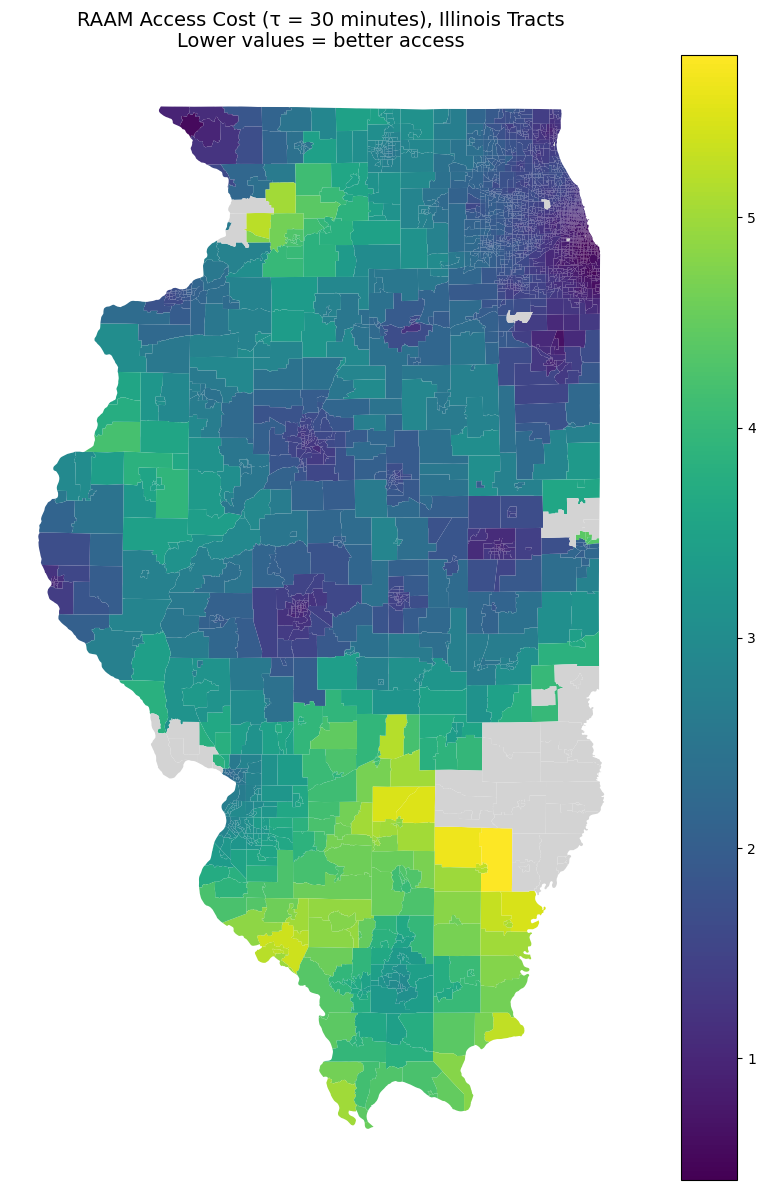

In [18]:
GEOGRAPHIES_IL_plot = GEOGRAPHIES_IL.to_crs("EPSG:4326").copy()

# Get bounding box of Illinois tracts
minx, miny, maxx, maxy = GEOGRAPHIES_IL_plot.total_bounds

# Add a small margin around the data
dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05

fig, ax = plt.subplots(1, 1, figsize=(10, 12))       # Illinois vertical layout

GEOGRAPHIES_IL_plot.plot(
    column="RAAM_30",
    ax=ax,
    cmap="viridis",
    legend=True,
    linewidth=0,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Zoom to Illinois extent (with padding)
ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

ax.set_title(
    "RAAM Access Cost (τ = 30 minutes), Illinois Tracts\nLower values = better access",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

#### 5.2 Compare RAAM (τ = 30 vs 60) for Illinois Tracts

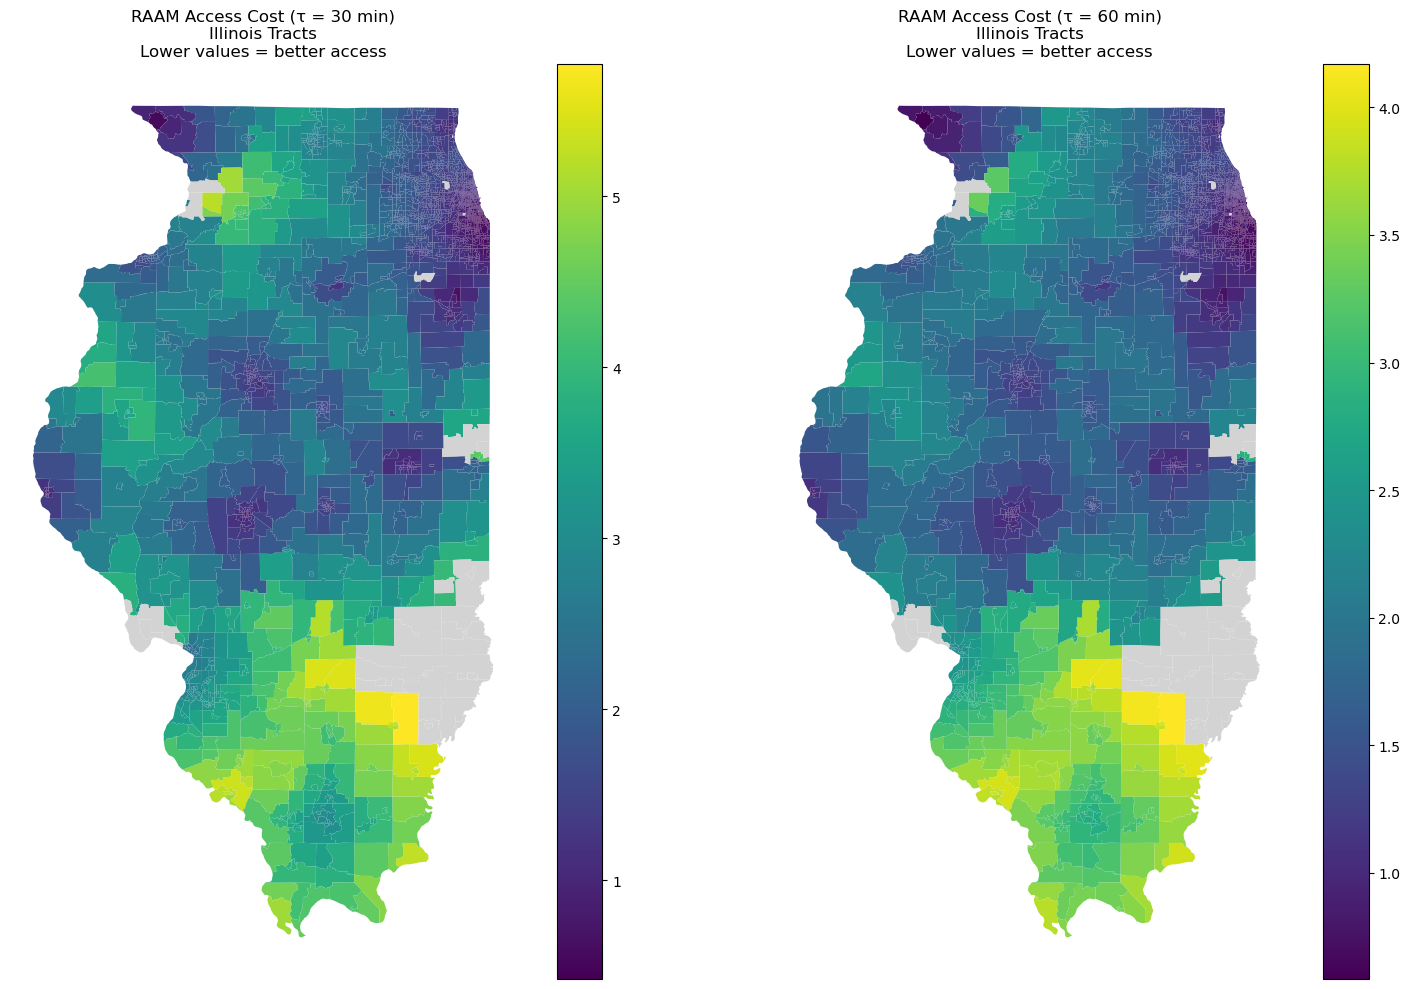

In [19]:
GEOGRAPHIES_IL_plot = GEOGRAPHIES_IL.to_crs("EPSG:4326").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

plot_kwargs = dict(
    cmap="viridis",
    linewidth=0,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Left: RAAM_30
GEOGRAPHIES_IL_plot.plot(
    column="RAAM_30",
    ax=axes[0],
    legend=True,
    **plot_kwargs
)
axes[0].set_title(
    "RAAM Access Cost (τ = 30 min)\nIllinois Tracts\nLower values = better access",
    fontsize=12
)
axes[0].set_axis_off()

# Right: RAAM_60
GEOGRAPHIES_IL_plot.plot(
    column="RAAM_60",
    ax=axes[1],
    legend=True,
    **plot_kwargs
)
axes[1].set_title(
    "RAAM Access Cost (τ = 60 min)\nIllinois Tracts\nLower values = better access",
    fontsize=12
)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Step 6: Export and Save

##### **Goal:**
- Save the final Illinois tract-level RAAM results (including geometry) in analysis- and GIS-friendly formats for downstream mapping, sharing, and reproducibility.
**Output**:
- Parquet file (GeoDataFrame preserved, geometry retained) containing Illinois tracts with demand, **RAAM_30**, and **RAAM_60**
- CSV file (geometry stored as WKT) containing the same Illinois RAAM outputs for non-spatial workflows

In [20]:
import os

output_dir = "raam_otp_il_outputs"
os.makedirs(output_dir, exist_ok=True)

# Make a copy to be safe
GEOGRAPHIES_IL_OTP = GEOGRAPHIES_IL.copy()

# Ensure clean 11-char GEOID
GEOGRAPHIES_IL_OTP["GEOID"] = GEOGRAPHIES_IL_OTP["GEOID"].astype(str).str.zfill(11)

# 1) Parquet with geometry (recommended for GIS work)
parquet_path = os.path.join(output_dir, "GEOGRAPHIES_IL_OTP_RAAM_2SFCA.parquet")
GEOGRAPHIES_IL_OTP.to_parquet(parquet_path, index=False)
print("Wrote Illinois OTP GeoDataFrame (with geometry) to:", parquet_path)

# 2) CSV with geometry as WKT
csv_path = os.path.join(output_dir, "GEOGRAPHIES_IL_OTP_RAAM_2SFCA_with_geom.csv")
GEOGRAPHIES_IL_OTP.to_csv(csv_path, index=False)
print("Wrote Illinois OTP CSV (including geometry as WKT) to:", csv_path)

Wrote Illinois OTP GeoDataFrame (with geometry) to: raam_otp_il_outputs/GEOGRAPHIES_IL_OTP_RAAM_2SFCA.parquet
Wrote Illinois OTP CSV (including geometry as WKT) to: raam_otp_il_outputs/GEOGRAPHIES_IL_OTP_RAAM_2SFCA_with_geom.csv
